# Klasyfikacja obrazów CIFAR-10 za pomocą sieci MLP
Na samym początku importuję wszystkie potrzebne biblioteki. Używam PyTorcha do budowy sieci neuronowej, a do wizualizacji wyników i wykresów posłuży mi matplotlib oraz seaborn. Od razu ładuję zbiór danych CIFAR-10 i dodaję transformację z normalizacją. Zrobiłem to po to, by przeskalować piksele obrazka do wartości od -1 do 1, co znacząco pomaga sieci w szybszym i stabilniejszym uczeniu

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import warnings

warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Będę trenować na: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Do eksploracji bierzemy mały batch
explore_loader = DataLoader(train_set, batch_size=4, shuffle=True)
images, labels = next(iter(explore_loader))

print(f"Kształt tensora danych (batch): {images.shape}")
print(f"Zakres wartości pikseli po normalizacji: {images.min().item()} do {images.max().item()}")

Będę trenować na: cpu
Kształt tensora danych (batch): torch.Size([4, 3, 32, 32])
Zakres wartości pikseli po normalizacji: -1.0 do 1.0


Zanim wrzucimy te dane do sieci, warto w ogóle zobaczyć, jak wyglądają i czy rozkład klas jest w miarę równy. Ponieważ CIFAR-10 ma obrazki 32x32 piksele, są one dla nas bardzo małe i niewyraźne. Poniższy kod wyświetla kilka przykładowych zdjęć oraz pokazuje, że każda z 10 klas w zbiorze treningowym ma dokładnie taką samą liczbę próbek (po 5000), więc zbiór jest idealnie zbalansowany.

Przykładowe obrazy ze zbioru:


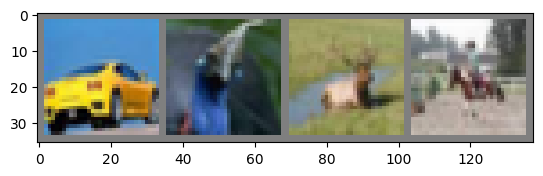

automobile | bird  | deer  | horse


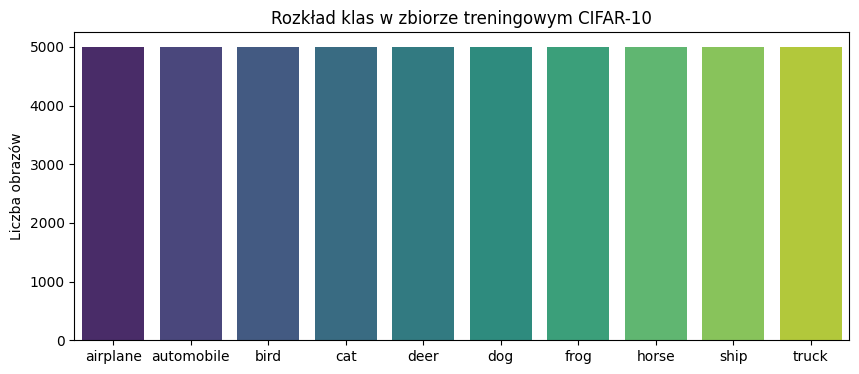

In [ ]:
classes = train_set.classes

def imshow(img):
    img = img / 2 + 0.5  
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

print("Przykładowe obrazy ze zbioru:")
imshow(torchvision.utils.make_grid(images))
print(" | ".join(f'{classes[labels[j]]:5s}' for j in range(4)))

# Wykres rozkładu klas
class_counts = [0] * 10
for _, label in train_set:
    class_counts[label] += 1

plt.figure(figsize=(10, 4))
sns.barplot(x=classes, y=class_counts, hue=classes, palette='viridis', legend=False)
plt.title("Rozkład klas w zbiorze treningowym CIFAR-10")
plt.ylabel("Liczba obrazów")
plt.show()

Przechodzimy do budowy samego modelu. Postawiłem na klasyczną sieć wielowarstwową (MLP). Na wejściu zastosowałem funkcję `Flatten()`, która po prostu bierze te nasze 3-kanałowe obrazki 32x32 i rozciąga je w jeden długi wektor o długości 3072 elementów. Dodałem dwie warstwy ukryte i użyłem funkcji aktywacji ReLU. Żeby model nie zapamiętał danych na pamięć (overfitting), wplotłem warstwy Dropout, które losowo "usypiają" część neuronów.

In [9]:
class CIFAR10MLP(nn.Module):
    def __init__(self, hidden1=512, hidden2=256, dropout_p=0.3):
        super(CIFAR10MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(32 * 32 * 3, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden2, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

# Definicja funkcji trenującej, która zwraca nam historię uczenia do wykresów
def train_model(model, train_loader, epochs=5, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {'loss': [], 'acc': []}
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100. * correct / total
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)
        print(f"Epoka {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}%")
        
    return history

Teraz przeprowadzę mały eksperyment, żeby sprawdzić, jak na proces uczenia wpływa zmiana współczynnika uczenia (Learning Rate). Przetestuję dwie skrajne wartości: 0.001 oraz bardzo wysoką 0.01. Użyję standardowego rozmiaru batcha równego 64 i zaledwie 5 epok, żeby szybko zobaczyć trend bez zbędnego czekania.

--- Eksperyment 1: Learning Rate = 0.01 ---
Epoka 1/5 | Loss: 2.2667 | Acc: 13.34%
Epoka 2/5 | Loss: 2.2719 | Acc: 12.46%
Epoka 3/5 | Loss: 2.3032 | Acc: 10.07%
Epoka 4/5 | Loss: 2.3044 | Acc: 9.99%
Epoka 5/5 | Loss: 2.3036 | Acc: 9.98%

--- Eksperyment 2: Learning Rate = 0.001 ---
Epoka 1/5 | Loss: 1.7766 | Acc: 36.59%
Epoka 2/5 | Loss: 1.6221 | Acc: 42.73%
Epoka 3/5 | Loss: 1.5564 | Acc: 44.79%
Epoka 4/5 | Loss: 1.5111 | Acc: 46.48%
Epoka 5/5 | Loss: 1.4795 | Acc: 47.46%


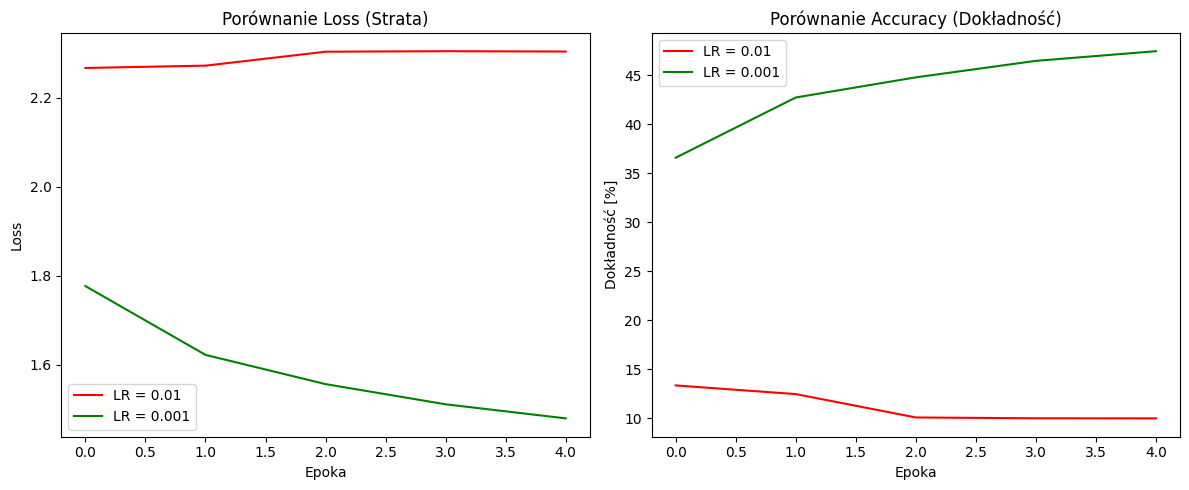

In [ ]:
train_loader_exp = DataLoader(train_set, batch_size=64, shuffle=True)

print("--- Eksperyment 1: Learning Rate = 0.01 ---")
model_bad_lr = CIFAR10MLP(256, 128).to(device)
hist_bad_lr = train_model(model_bad_lr, train_loader_exp, epochs=5, lr=0.01)

print("\n--- Eksperyment 2: Learning Rate = 0.001 ---")
model_good_lr = CIFAR10MLP(256, 128).to(device)
hist_good_lr = train_model(model_good_lr, train_loader_exp, epochs=5, lr=0.001)

plt.figure(figsize=(12, 5))

# Wykres funkcji straty
plt.subplot(1, 2, 1)
plt.plot(hist_bad_lr['loss'], label='LR = 0.01', color='red')
plt.plot(hist_good_lr['loss'], label='LR = 0.001', color='green')
plt.title('Porównanie Loss (Strata)')
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()

# Wykres dokładności
plt.subplot(1, 2, 2)
plt.plot(hist_bad_lr['acc'], label='LR = 0.01', color='red')
plt.plot(hist_good_lr['acc'], label='LR = 0.001', color='green')
plt.title('Porównanie Accuracy (Dokładność)')
plt.xlabel('Epoka')
plt.ylabel('Dokładność [%]')
plt.legend()

plt.tight_layout()
plt.show()

Jak widać na powyższych wykresach, dobór hiperparametrów potrafi "zrobić lub zepsuć" model. Przy zbyt wysokim parametrze (LR = 0.01, czerwona linia) strata modelu wcale mocno nie maleje, a model "skacze" oscylując w okolicach niskiej dokładności. Z kolei przy wartości 0.001 uczenie przebiega stabilnie, linia błędu płynnie spada w dół, a trafność predykcji rośnie.

Bazując na tym, zbuduję i wytrenuję ostateczny, większy model (512 neuronów w pierwszej warstwie), z poprawnym learning rate (0.001). To na nim wygenerujemy docelowe metryki i macierz pomyłek.

In [ ]:
print("Trenowanie najlepszego wybranego modelu...")
best_model = CIFAR10MLP(hidden1=512, hidden2=256, dropout_p=0.3).to(device)
train_loader_final = DataLoader(train_set, batch_size=64, shuffle=True)

hist_final = train_model(best_model, train_loader_final, epochs=10, lr=0.001)

Trenowanie najlepszego wybranego modelu...
Epoka 1/10 | Loss: 1.7460 | Acc: 38.01%
Epoka 2/10 | Loss: 1.6017 | Acc: 43.71%
Epoka 3/10 | Loss: 1.5419 | Acc: 45.82%
Epoka 4/10 | Loss: 1.4942 | Acc: 47.14%
Epoka 5/10 | Loss: 1.4569 | Acc: 48.37%
Epoka 6/10 | Loss: 1.4202 | Acc: 49.79%
Epoka 7/10 | Loss: 1.3907 | Acc: 50.77%
Epoka 8/10 | Loss: 1.3676 | Acc: 51.53%
Epoka 9/10 | Loss: 1.3387 | Acc: 52.52%
Epoka 10/10 | Loss: 1.3238 | Acc: 52.92%


Przepuszczam przez wytrenowaną sieć dane testowe (których wcześniej nie widziała) i zestawiam to, co przewidziała, z tym co jest prawdą. Wyświetlona niżej macierz pomyłek pozwala intuicyjnie odczytać, w jakich obszarach sieć najczęściej głupieje.

--- Raport klasyfikacji ---
              precision    recall  f1-score   support

    airplane       0.57      0.58      0.57      1000
  automobile       0.63      0.68      0.65      1000
        bird       0.43      0.36      0.39      1000
         cat       0.34      0.37      0.36      1000
        deer       0.47      0.42      0.44      1000
         dog       0.38      0.50      0.43      1000
        frog       0.59      0.57      0.58      1000
       horse       0.68      0.52      0.59      1000
        ship       0.63      0.67      0.65      1000
       truck       0.58      0.56      0.57      1000

    accuracy                           0.52     10000
   macro avg       0.53      0.52      0.52     10000
weighted avg       0.53      0.52      0.52     10000



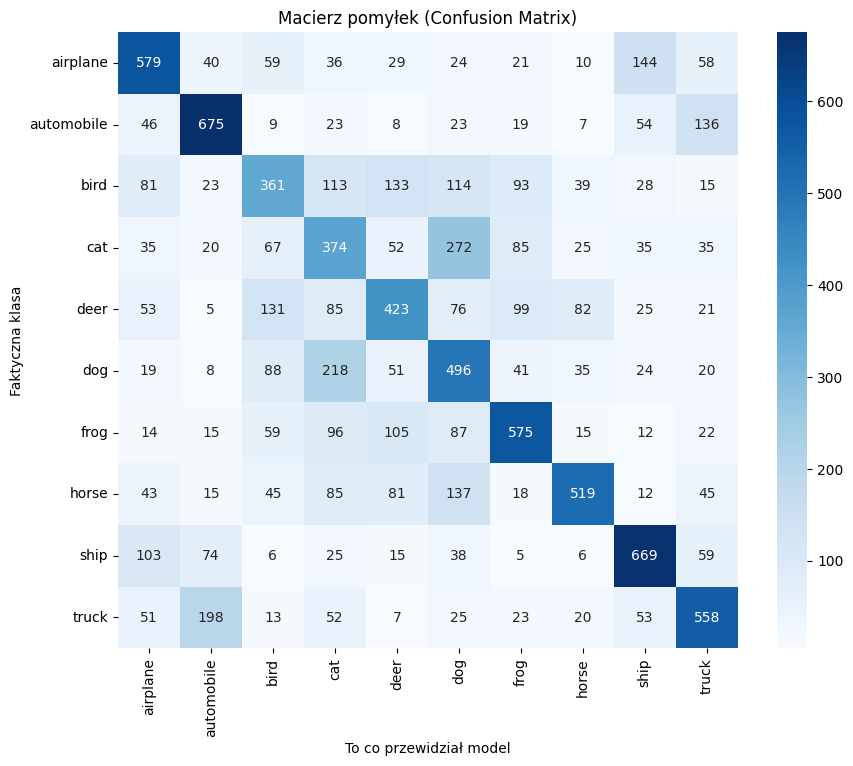

In [ ]:
test_loader_final = DataLoader(test_set, batch_size=64, shuffle=False)
best_model.eval() 

all_preds = []
all_labels = []
misclassified_images = []
misclassified_labels = []
misclassified_preds = []

with torch.no_grad():
    for images, labels in test_loader_final:
        images, labels = images.to(device), labels.to(device)
        outputs = best_model(images)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        for i in range(len(labels)):
            if predicted[i] != labels[i] and len(misclassified_images) < 4:
                misclassified_images.append(images[i].cpu())
                misclassified_labels.append(labels[i].cpu().item())
                misclassified_preds.append(predicted[i].cpu().item())

print("--- Raport klasyfikacji ---")
print(classification_report(all_labels, all_preds, target_names=classes))

# Macierz pomyłek
conf_matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Macierz pomyłek (Confusion Matrix)")
plt.xlabel("To co przewidział model")
plt.ylabel("Faktyczna klasa")
plt.show()

Raport i macierz pomyłek mówią bardzo wiele. Nasz prosty MLP radzi sobie w miarę nieźle z wyraźnie różniącymi się obiektami takimi jak auta (`automobile`) czy żaby (`frog`), ale kompletnie gubi się pomiędzy psami a kotami (silne zagęszczenie pomyłek na wykresie). Wynika to z natury sieci w pełni połączonej – spłaszczając obraz do jednowymiarowego wektora za pomocą `Flatten()`, bezpowrotnie niszczymy relacje przestrzenne między pikselami. Sieć po prostu próbuje zgadywać na podstawie ogólnych kolorów zdjęć. Zobaczmy to na własne oczy na poniższych przykładach błędów.

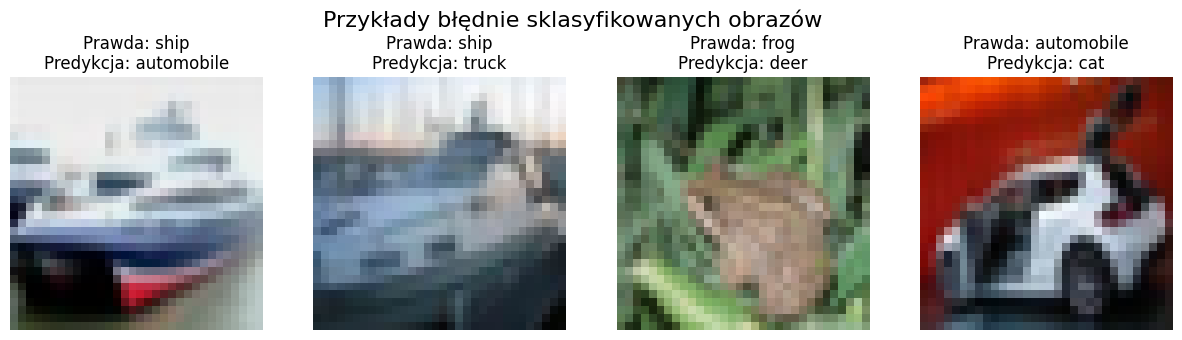

In [ ]:
# Wizualizacja błędów 
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
fig.suptitle("Przykłady błędnie sklasyfikowanych obrazów", fontsize=16)

for i in range(4):
    img = misclassified_images[i] / 2 + 0.5 
    npimg = img.numpy()
    axes[i].imshow(np.transpose(npimg, (1, 2, 0)))
    true_label = classes[misclassified_labels[i]]
    pred_label = classes[misclassified_preds[i]]
    axes[i].set_title(f"Prawda: {true_label}\nPredykcja: {pred_label}")
    axes[i].axis('off')

plt.show()

**Wnioski końcowe:**
Zadanie pokazało mi "w boju", jak ważny jest dobór takich parametrów jak Learning Rate czy architektura. Moja sieć MLP na zbiorze CIFAR-10 osiągnęła dokładność (accuracy) w granicach 50%. Biorąc pod uwagę, że losowe zgadywanie dawałoby 10%, jest to spory sukces dla tak prostej architektury, jednak do komercyjnych zastosowań wynik ten byłby nieakceptowalny.

Na podstawie wyłapanych błędów wizualnych widać, że jeśli tło ptaka jest zielone jak żaby, model przypisze tam klasę żaby. Do poważniejszej obróbki takich zdjęć, gdzie liczą się krawędzie i kształty (uszy kota vs pysk psa), należałoby w przyszłości zaimplementować splotowe sieci neuronowe (CNN), a nie zwykłego Perceptronu.